In [1]:
from typing import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from core.feature_type import FeatureType
from feature_writer.FeatureWriter import REGRESSOR_OFFSETS
from analysis.utils.build_dataset import create_dataset

# Load data from pumps/cross_sections
df: pd.DataFrame = create_dataset()
df["is_pumped"] = df["currency_pair"] == df["pumped_currency_pair"]  # create bool column is_pumped

Building dataset:  18%|█▊        | 90/498 [00:00<00:01, 243.58it/s]2025-09-11 19:28:34,487 | INFO | root | No cross section found for pump CRACK-BTC-BINANCE_SPOT-2021-08-07T12-00-24
2025-09-11 19:28:34,487 | INFO | root | No cross section found for pump CREA-BTC-BINANCE_SPOT-2021-07-28T12-00-09
2025-09-11 19:28:34,488 | INFO | root | No cross section found for pump CRUMB-BTC-BINANCE_SPOT-2021-07-26T12-00-09
2025-09-11 19:28:34,488 | INFO | root | No cross section found for pump CTCX-BTC-BINANCE_SPOT-2020-06-03T16-00-12
2025-09-11 19:28:34,506 | INFO | root | No cross section found for pump CURE-BTC-BINANCE_SPOT-2019-03-19T20-01-23
Building dataset:  25%|██▍       | 124/498 [00:00<00:01, 277.11it/s]2025-09-11 19:28:34,605 | INFO | root | No cross section found for pump DTB-BTC-BINANCE_SPOT-2019-03-28T20-00-55
2025-09-11 19:28:34,643 | INFO | root | No cross section found for pump ETHOS-BTC-BINANCE_SPOT-2019-04-01T17-00-13
Building dataset:  33%|███▎      | 163/498 [00:00<00:01, 314.42it

In [2]:
df.shape

(91822, 90)

In [3]:
# Overall we have data for 465 pumps
df["pump_hash"].nunique()

470

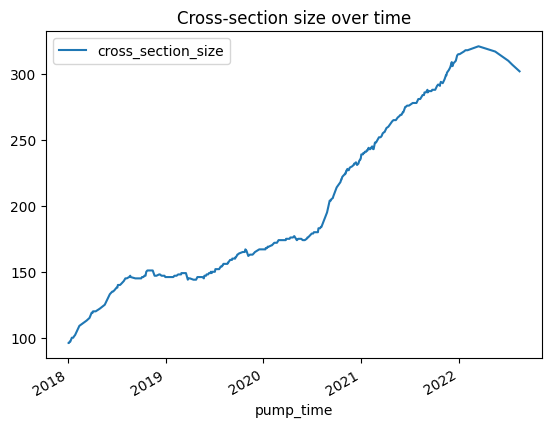

In [4]:
# cross-section statistics
(
    df.groupby("pump_hash")
    .agg(
        pump_time=("pump_time", "first"),
        cross_section_size=("pump_time", "count")
    )
    .sort_values(by="pump_time", ascending=True)
    .plot(x="pump_time", y="cross_section_size", title="Cross-section size over time")
)
plt.show()

<h4>Feature distributions and cross-sectional standardisation</h4>

In [5]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

<p>Now we will go through each FeatureType and display distribution stats and fix gaps in data</p>

<h4>Powerlaw features</h4>

In [6]:
powerlaw_cols: List[str] = FeatureType.POWERLAW_ALPHA.col_names(offsets=REGRESSOR_OFFSETS)
df[powerlaw_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
powerlaw_alpha@5MIN,82029.0,inf,NaN,-9.007199e+15,1.288120,1.425208,1.817880,inf
powerlaw_alpha@15MIN,89206.0,inf,NaN,-9.007199e+15,1.240172,1.324583,1.465053,inf
powerlaw_alpha@1H,90990.0,inf,NaN,1.087056e+00,1.199191,1.255604,1.331948,inf
powerlaw_alpha@2H,91035.0,inf,NaN,1.083316e+00,1.182918,1.231734,1.296228,inf
powerlaw_alpha@4H,91049.0,inf,NaN,1.087441e+00,1.168608,1.212648,1.266689,inf
powerlaw_alpha@12H,91070.0,1.203983,0.079888,1.085992e+00,1.153710,1.191172,1.234612,4.958618
powerlaw_alpha@1D,91073.0,1.191799,0.068972,1.084541e+00,1.147271,1.179958,1.220098,4.713602
powerlaw_alpha@2D,91122.0,1.181512,0.061280,1.042519e+00,1.141730,1.170914,1.208095,4.552822
powerlaw_alpha@7D,91291.0,1.168176,0.048358,1.041700e+00,1.134245,1.159033,1.192701,2.326308
powerlaw_alpha@14D,91463.0,1.162654,0.044172,1.041700e+00,1.130798,1.154227,1.186271,2.035152


In [7]:
# clip pawerlaw features to range [1, 2]
df[powerlaw_cols] = df[powerlaw_cols].clip(1, 2)
df[powerlaw_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
powerlaw_alpha@5MIN,82029.0,1.532397,0.296135,1.000000,1.288120,1.425208,1.817880,2.0
powerlaw_alpha@15MIN,89206.0,1.398867,0.233550,1.000000,1.240172,1.324583,1.465053,2.0
powerlaw_alpha@1H,90990.0,1.283074,0.132187,1.087056,1.199191,1.255604,1.331948,2.0
powerlaw_alpha@2H,91035.0,1.251094,0.103673,1.083316,1.182918,1.231734,1.296228,2.0
powerlaw_alpha@4H,91049.0,1.228093,0.088800,1.087441,1.168608,1.212648,1.266689,2.0
powerlaw_alpha@12H,91070.0,1.203716,0.074676,1.085992,1.153710,1.191172,1.234612,2.0
powerlaw_alpha@1D,91073.0,1.191680,0.066330,1.084541,1.147271,1.179958,1.220098,2.0
powerlaw_alpha@2D,91122.0,1.181404,0.058564,1.042519,1.141730,1.170914,1.208095,2.0
powerlaw_alpha@7D,91291.0,1.168168,0.048194,1.041700,1.134245,1.159033,1.192701,2.0
powerlaw_alpha@14D,91463.0,1.162653,0.044158,1.041700,1.130798,1.154227,1.186271,2.0


In [8]:
df[powerlaw_cols].isna().sum()

powerlaw_alpha@5MIN     9793
powerlaw_alpha@15MIN    2616
powerlaw_alpha@1H        832
powerlaw_alpha@2H        787
powerlaw_alpha@4H        773
powerlaw_alpha@12H       752
powerlaw_alpha@1D        749
powerlaw_alpha@2D        700
powerlaw_alpha@7D        531
powerlaw_alpha@14D       359
dtype: int64

In [9]:
df[powerlaw_cols] = df[powerlaw_cols].fillna(-1)

<h4>Asset return features</h4>

<p><b>Note: returns are measured in pips</b></p>
<p>Here we observe that anticipated behaviour as time window grows the min/max and std become higher in absolute terms</p>

In [10]:
asset_return_cols: List[str] = FeatureType.ASSET_RETURN.col_names(offsets=REGRESSOR_OFFSETS)
df[asset_return_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
asset_return@5MIN,82028.0,3.518897,142.435802,-3333.333333,-19.057904,0.000000,20.682523,7000.000000
asset_return@15MIN,89205.0,5.079787,167.572388,-3333.333333,-31.055901,0.000000,34.566194,7000.000000
asset_return@1H,90988.0,7.320130,231.713081,-3528.125000,-65.769263,0.000000,63.853850,7288.135593
asset_return@2H,91028.0,7.478144,289.099667,-5000.000000,-96.566524,0.000000,82.644628,12371.541502
asset_return@4H,91034.0,19.540937,364.351492,-3875.968992,-127.388535,0.000000,121.988965,12549.800797
asset_return@12H,91013.0,33.848512,675.188398,-6392.125806,-211.742060,0.000000,202.020202,119032.258065
asset_return@1D,90998.0,28.715648,871.644770,-4814.814815,-334.951570,-28.425251,267.857143,119032.258065
asset_return@2D,90965.0,-2.079513,1215.217670,-6050.000000,-508.666775,-80.223230,324.675325,119032.258065
asset_return@7D,90368.0,4.529507,4323.382384,-9999.946672,-1081.081081,-231.052107,605.382301,979361.702128
asset_return@14D,89709.0,54.288893,6549.287540,-9999.952116,-1607.142857,-409.484275,859.728507,979361.702128


In [11]:
df[asset_return_cols].isna().sum()

asset_return@5MIN     9794
asset_return@15MIN    2617
asset_return@1H        834
asset_return@2H        794
asset_return@4H        788
asset_return@12H       809
asset_return@1D        824
asset_return@2D        857
asset_return@7D       1454
asset_return@14D      2113
dtype: int64

<h4>Asset return zscores</h4>

In [12]:
asset_return_zscore_cols: List[str] = FeatureType.ASSET_RETURN_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
df[asset_return_zscore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
asset_return_zscore@5MIN,80075.0,0.062493,1.245983,-14.091035,-0.460395,0.000000,0.452818,25.383653
asset_return_zscore@15MIN,80075.0,0.062493,1.245983,-14.091035,-0.460395,0.000000,0.452818,25.383653
asset_return_zscore@1H,91020.0,0.062696,1.011714,-14.091035,-0.380165,0.000000,0.399116,20.413539
asset_return_zscore@2H,91044.0,0.043599,0.734510,-7.602639,-0.299493,0.000000,0.301992,13.955420
asset_return_zscore@4H,91049.0,0.038682,0.541725,-6.030088,-0.220581,0.000668,0.228209,13.955420
asset_return_zscore@12H,91069.0,0.023407,0.301217,-2.251391,-0.124178,0.001195,0.137317,6.795124
asset_return_zscore@1D,91072.0,0.007774,0.194450,-1.767127,-0.097485,-0.005886,0.095271,1.892111
asset_return_zscore@2D,91119.0,-0.001543,0.136069,-2.123060,-0.075063,-0.007667,0.063371,4.823023
asset_return_zscore@7D,91285.0,-0.003213,0.081364,-2.123060,-0.046465,-0.004116,0.038736,4.974488
asset_return_zscore@14D,91454.0,-0.002702,0.061601,-2.308614,-0.035278,-0.002513,0.029946,4.972071


In [13]:
df[asset_return_zscore_cols].isna().sum()

asset_return_zscore@5MIN     11747
asset_return_zscore@15MIN    11747
asset_return_zscore@1H         802
asset_return_zscore@2H         778
asset_return_zscore@4H         773
asset_return_zscore@12H        753
asset_return_zscore@1D         750
asset_return_zscore@2D         703
asset_return_zscore@7D         537
asset_return_zscore@14D        368
dtype: int64

<h4>Quote abs zscore</h4>

In [14]:
quote_abs_zscore_cols: List[str] = FeatureType.QUOTE_ABS_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
df[quote_abs_zscore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
quote_abs_zscore@5MIN,80075.0,0.714665,1.352324,0.000032,0.125550,0.324353,0.774588,26.408984
quote_abs_zscore@15MIN,80075.0,0.714665,1.352324,0.000032,0.125550,0.324353,0.774588,26.408984
quote_abs_zscore@1H,91020.0,0.708528,1.230413,0.000011,0.138924,0.341154,0.793590,26.408984
quote_abs_zscore@2H,91044.0,0.691601,1.049857,0.000035,0.153069,0.358527,0.802558,17.311744
quote_abs_zscore@4H,91049.0,0.676335,0.907536,0.000124,0.167767,0.377638,0.812870,11.531047
quote_abs_zscore@12H,91069.0,0.606273,0.679720,0.000598,0.176698,0.379598,0.771263,7.441625
quote_abs_zscore@1D,91072.0,0.574312,0.582387,0.000713,0.183519,0.383148,0.751881,5.185480
quote_abs_zscore@2D,91119.0,0.571212,0.509663,0.000392,0.206726,0.413271,0.773989,5.133345
quote_abs_zscore@7D,91285.0,0.571705,0.398342,0.000392,0.273022,0.485866,0.781749,4.978211
quote_abs_zscore@14D,91454.0,0.573626,0.350301,0.000481,0.322201,0.511517,0.763366,4.978211


<h4>Share of long trades</h4>

In [15]:
share_of_long_trades_cols: List[str] = FeatureType.SHARE_OF_LONG_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
df[share_of_long_trades_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
share_of_long_trades@5MIN,82029.0,0.517428,0.292993,0.000000,0.333333,0.500000,0.714286,1.000000
share_of_long_trades@15MIN,89206.0,0.518827,0.225130,0.000000,0.388889,0.518072,0.666667,1.000000
share_of_long_trades@1H,90990.0,0.517206,0.150588,0.000000,0.433071,0.517274,0.604027,1.000000
share_of_long_trades@2H,91035.0,0.516094,0.124571,0.000000,0.447368,0.515829,0.586207,1.000000
share_of_long_trades@4H,91049.0,0.517529,0.106388,0.000000,0.460546,0.515971,0.574405,1.000000
share_of_long_trades@12H,91070.0,0.518438,0.090566,0.000000,0.473091,0.516129,0.562343,0.995282
share_of_long_trades@1D,91073.0,0.519985,0.080569,0.028927,0.481559,0.516490,0.555388,0.993056
share_of_long_trades@2D,91122.0,0.521072,0.072661,0.047204,0.486984,0.516176,0.550401,0.989017
share_of_long_trades@7D,91291.0,0.523150,0.064068,0.083655,0.494242,0.516987,0.545692,0.976714
share_of_long_trades@14D,91463.0,0.525049,0.060112,0.093449,0.497402,0.517709,0.545073,0.962848


<h4>Slippage imbalance</h4>

In [16]:
slippage_imbalance_cols: List[str] = FeatureType.SLIPPAGE_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
df[slippage_imbalance_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
slippage_imbalance@5MIN,51195.0,-0.045869,0.894422,-1.0,-1.000000,-0.204003,1.000000,1.0
slippage_imbalance@15MIN,70595.0,-0.062514,0.840182,-1.0,-0.992633,-0.185185,0.939394,1.0
slippage_imbalance@1H,85480.0,-0.104280,0.736842,-1.0,-0.853547,-0.201580,0.621636,1.0
slippage_imbalance@2H,88441.0,-0.120402,0.674151,-1.0,-0.758308,-0.192062,0.466959,1.0
slippage_imbalance@4H,89855.0,-0.123286,0.613080,-1.0,-0.661039,-0.175173,0.360466,1.0
slippage_imbalance@12H,90712.0,-0.126921,0.530006,-1.0,-0.533111,-0.155822,0.238249,1.0
slippage_imbalance@1D,90948.0,-0.130025,0.479187,-1.0,-0.467924,-0.153024,0.176611,1.0
slippage_imbalance@2D,91086.0,-0.129458,0.425367,-1.0,-0.402960,-0.144050,0.120465,1.0
slippage_imbalance@7D,91289.0,-0.109082,0.341502,-1.0,-0.299627,-0.120601,0.069780,1.0
slippage_imbalance@14D,91463.0,-0.099476,0.303354,-1.0,-0.259451,-0.111194,0.052821,1.0


In [17]:
df[slippage_imbalance_cols].isna().sum()

slippage_imbalance@5MIN     40627
slippage_imbalance@15MIN    21227
slippage_imbalance@1H        6342
slippage_imbalance@2H        3381
slippage_imbalance@4H        1967
slippage_imbalance@12H       1110
slippage_imbalance@1D         874
slippage_imbalance@2D         736
slippage_imbalance@7D         533
slippage_imbalance@14D        359
dtype: int64

<h4>Flow imbalance</h4>

In [18]:
flow_imbalance_cols: List[str] = FeatureType.FLOW_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
df[flow_imbalance_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
flow_imbalance@5MIN,82029.0,-0.012958,0.704885,-1.000000,-0.681938,-0.019778,0.647017,1.000000
flow_imbalance@15MIN,89206.0,-0.029279,0.582624,-1.000000,-0.482793,-0.030881,0.406859,1.000000
flow_imbalance@1H,90990.0,-0.045967,0.413064,-1.000000,-0.309430,-0.042736,0.208015,1.000000
flow_imbalance@2H,91035.0,-0.051872,0.335100,-1.000000,-0.248450,-0.045389,0.140368,1.000000
flow_imbalance@4H,91049.0,-0.046245,0.271332,-1.000000,-0.194892,-0.040011,0.100184,1.000000
flow_imbalance@12H,91070.0,-0.039650,0.202098,-1.000000,-0.143600,-0.037692,0.059172,0.993480
flow_imbalance@1D,91073.0,-0.034468,0.166173,-0.976580,-0.117438,-0.035296,0.039467,0.984582
flow_imbalance@2D,91122.0,-0.031970,0.138853,-0.976174,-0.100412,-0.035717,0.024487,0.967960
flow_imbalance@7D,91291.0,-0.023627,0.107374,-0.958871,-0.077090,-0.031485,0.012384,0.932742
flow_imbalance@14D,91463.0,-0.018778,0.096805,-0.895483,-0.068164,-0.028429,0.010742,0.907893


<h4>Num trades</h4>

In [19]:
num_trades_cols: List[str] = FeatureType.NUM_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
df[num_trades_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_trades@5MIN,91822.0,31.976934,100.461959,0.0,2.0,8.0,25.00,4987.0
num_trades@15MIN,91822.0,95.406112,276.191328,0.0,9.0,27.0,76.00,12184.0
num_trades@1H,91822.0,394.250049,1063.902051,0.0,47.0,122.0,329.00,33566.0
num_trades@2H,91822.0,783.780194,2105.338458,0.0,101.0,251.0,665.00,88326.0
num_trades@4H,91822.0,1543.024591,4019.396659,0.0,212.0,515.0,1341.00,137259.0
num_trades@12H,91822.0,4297.981475,10910.357757,0.0,634.0,1513.0,3810.00,437471.0
num_trades@1D,91822.0,8439.401059,21242.814332,0.0,1304.0,3041.0,7524.00,855882.0
num_trades@2D,91822.0,16918.377382,41222.376765,0.0,2791.0,6354.5,15298.00,1302688.0
num_trades@7D,91822.0,59346.896822,134528.579654,0.0,11271.0,24215.5,55280.50,3823480.0
num_trades@14D,91822.0,117406.986833,255666.161401,0.0,24167.0,49928.5,111832.25,6704862.0


In [20]:
# overall NaNs
df[df.isna().any(axis=1)].shape

(55023, 90)

<h4>Plot feature distributions before and after cross-sectional standardisation</h4>

$$X_{\text{std}} = \frac{X - \bar{X}}{\sigma_{X}}$$

In [21]:
# plot feature distributions before cross-sectional standardisation
cols_to_scale: List[str] = (
        asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols + powerlaw_cols
)

dfs: List[pd.DataFrame] = []

for pump_hash, df_cross_section in tqdm(df.groupby("pump_hash")):
    df_cross_section = df_cross_section.reset_index(drop=True)
    for col in cols_to_scale:
        df_cross_section[col] = (df_cross_section[col] - df_cross_section[col].mean()) / df_cross_section[col].std()
    dfs.append(df_cross_section)

df_scaled: pd.DataFrame = pd.concat(dfs)
df_scaled = df_scaled.reset_index(drop=True)
df_scaled.head(2)

100%|██████████| 470/470 [00:02<00:00, 184.15it/s]


,asset_return@5MIN,asset_return_zscore@5MIN,quote_abs_zscore@5MIN,share_of_long_trades@5MIN,powerlaw_alpha@5MIN,slippage_imbalance@5MIN,flow_imbalance@5MIN,num_trades@5MIN,asset_return@15MIN,asset_return_zscore@15MIN,...,target_return@1MIN,target_return@2MIN,target_return@3MIN,target_return@4MIN,target_return@5MIN,currency_pair,pump_hash,pump_time,pumped_currency_pair,is_pumped
0,-3.065219,0.075374,0.569709,0.000000,0.278581,NaN,-1.00000,2,-1.947783,0.075374,...,0.000000,0.000000,0.00000,0.000000,0.000000,REEF-BTC,ACM-BTC-BINANCE_SPOT-2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False
1,0.998692,-0.019388,-0.306953,0.647059,0.254699,1.0,-0.08256,17,2.421435,-0.019388,...,-10.373444,-145.228216,-77.80083,-57.053942,-93.360996,SUPER-BTC,ACM-BTC-BINANCE_SPOT-2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False


8it [00:02,  3.47it/s]


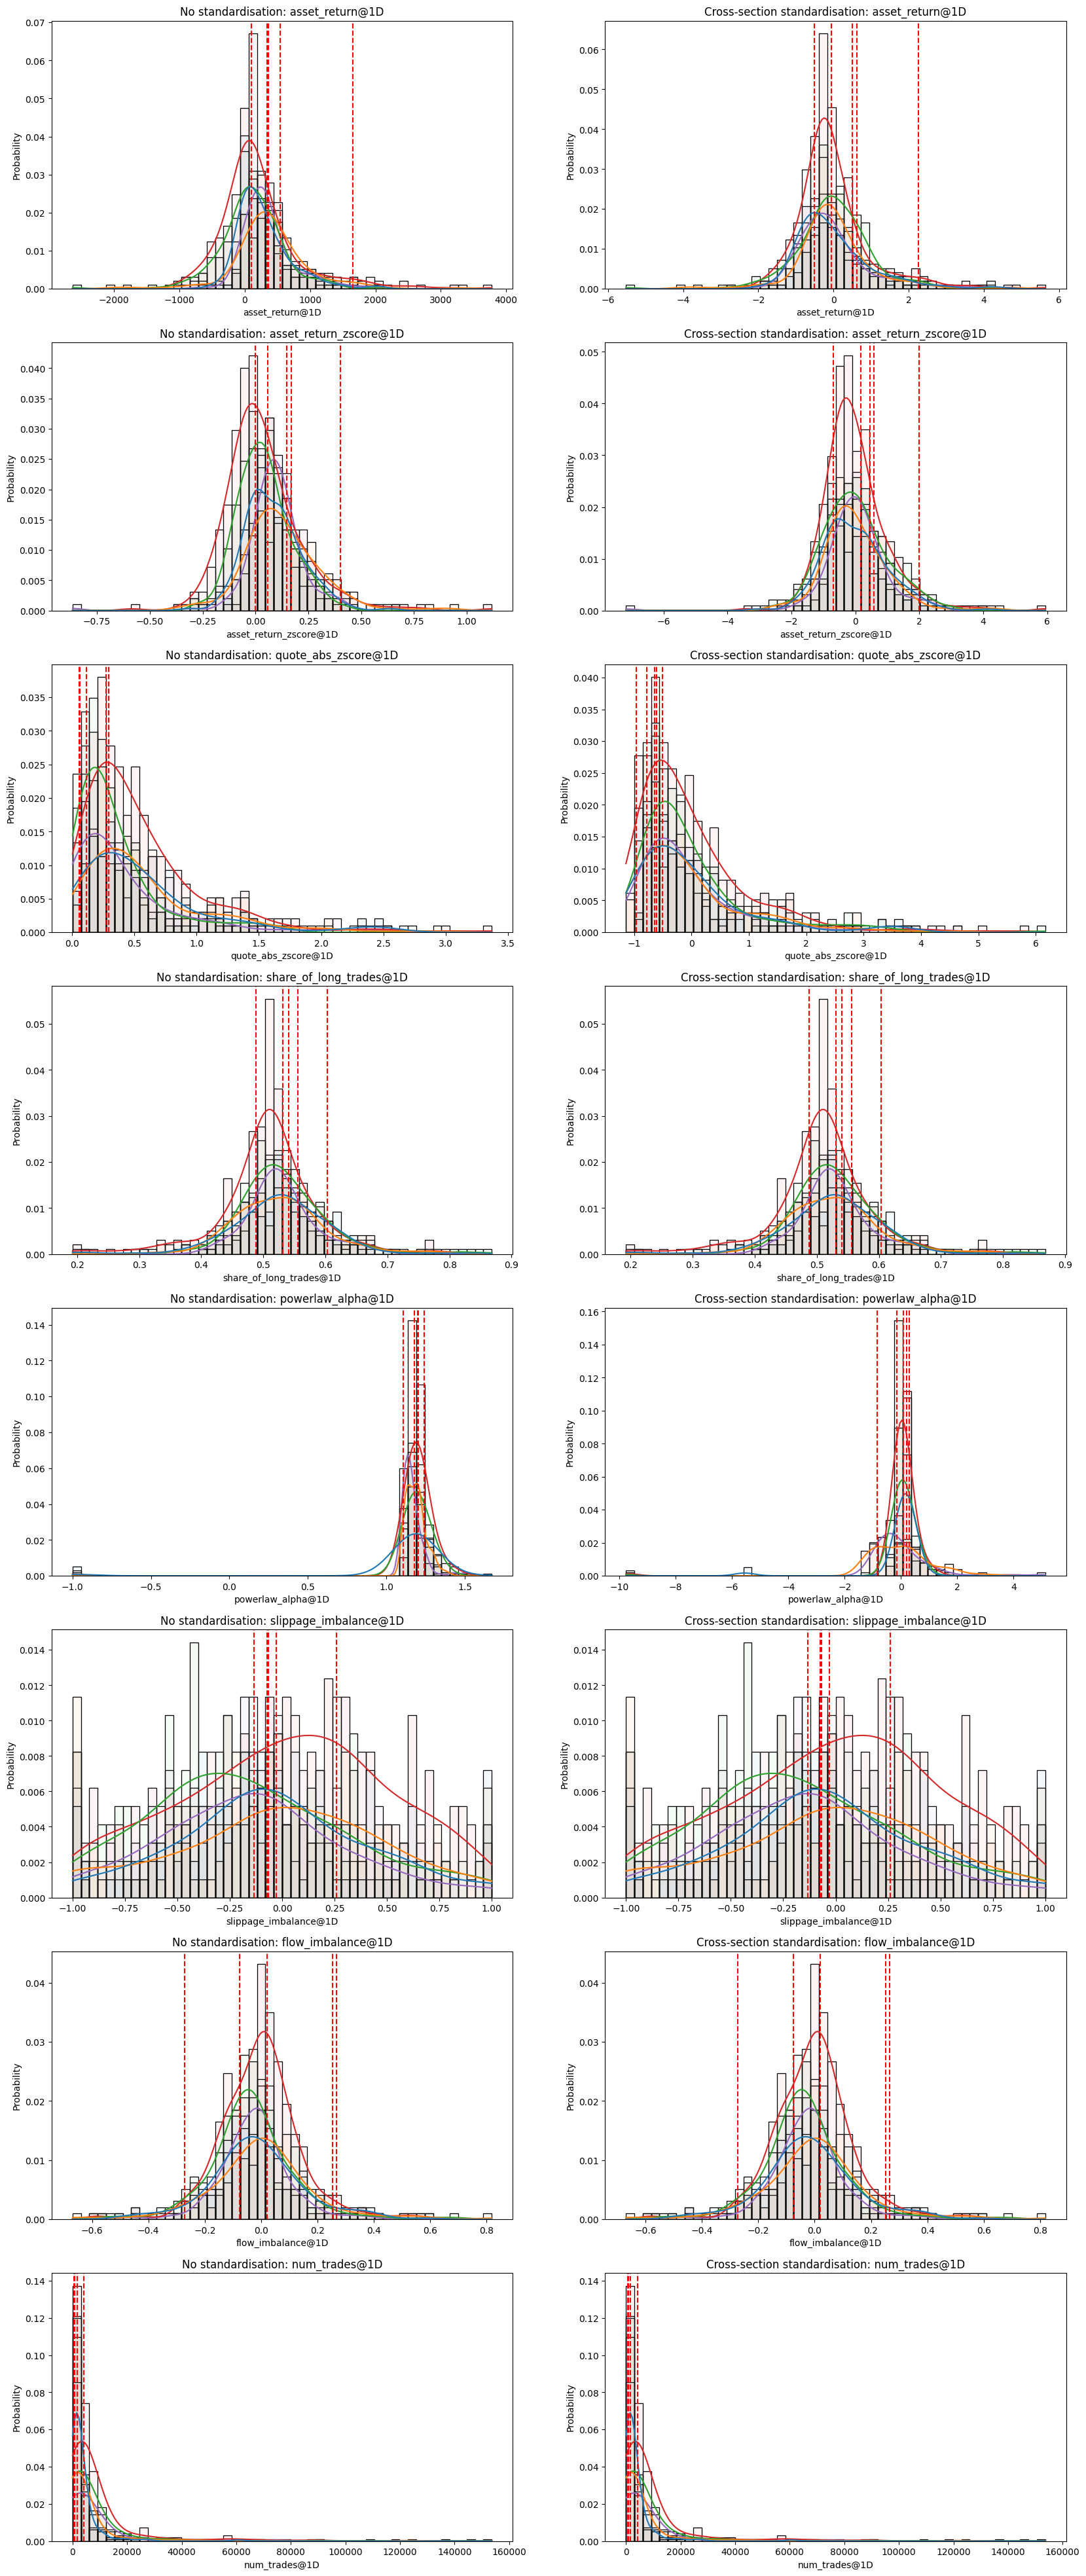

In [22]:
from core.time_utils import NamedTimeDelta
import seaborn as sns

fig, axs = plt.subplots(len(FeatureType), 2, figsize=(20, 50))
use_offset: NamedTimeDelta = NamedTimeDelta.ONE_DAY

# create two smaller dataframes with less cross-sections to plot
selected_pump_hashes: np.array = np.random.choice(df["pump_hash"].unique(), 5,
                                                  replace=False)  # use 5 pumps for plotting
df_small: pd.DataFrame = df[df["pump_hash"].isin(selected_pump_hashes)]
df_scaled_small: pd.DataFrame = df_scaled[df_scaled["pump_hash"].isin(selected_pump_hashes)]

feature: FeatureType

for (ax1, ax2), feature in tqdm(zip(axs, list(FeatureType))):
    col_name: str = feature.col_name(offset=use_offset)
    # Plot pumps without standardisation
    sns.histplot(
        data=df_small,
        x=col_name,
        hue="pump_hash",
        ax=ax1, legend=False, alpha=0.05, bins=50, kde=True, stat="probability"
    )
    ax1.set_title(f"No standardisation: {col_name}")
    for pump_hash in selected_pump_hashes:
        ax1.axvline(
            x=df_small.loc[df_small["is_pumped"] & (df_small["pump_hash"] == pump_hash), col_name].iloc[0],
            color="red", linestyle="--"
        )

    sns.histplot(
        data=df_scaled_small,
        x=col_name,
        hue="pump_hash",
        ax=ax2, legend=False, alpha=0.05, bins=50, kde=True, stat="probability"
    )
    ax2.set_title(f"Cross-section standardisation: {col_name}")
    for pump_hash in selected_pump_hashes:
        ax2.axvline(
            x=df_scaled_small.loc[
                df_scaled_small["is_pumped"] & (df_scaled_small["pump_hash"] == pump_hash), col_name].iloc[0],
            color="red", linestyle="--"
        )

<h4>Split data and train the first model</h4>

In [23]:
# Train/val/test split
df_train, df_val, df_test = (
    df_scaled[df_scaled["pump_time"] <= "2020-09-01"].copy(),  # train sample
    df_scaled[(df_scaled["pump_time"] > "2020-09-01") & (df_scaled["pump_time"] <= "2021-05-01")].copy(),  # val sample
    df_scaled[df_scaled["pump_time"] > "2021-05-01"].copy(),  # test sample
)

# Sample statistics
pumps = np.array([df_train["is_pumped"].sum(), df_val["is_pumped"].sum(), df_test["is_pumped"].sum()])
overall_observations = np.array([df_train.shape[0], df_val.shape[0], df_test.shape[0]])

avg_cross = np.array([
    df_train.groupby("pump_hash")["currency_pair"].count().mean(),
    df_val.groupby("pump_hash")["currency_pair"].count().mean(),
    df_test.groupby("pump_hash")["currency_pair"].count().mean()
])

df_cross_stats = pd.DataFrame({to
    "Positive": pumps,
    "Negative": overall_observations - pumps,
    "Total": overall_observations,
    "Average Crosssection Size": avg_cross
}).T.round(1)

df_cross_stats.columns = ["Train", "Validation", "Test"]
df_cross_stats

,Train,Validation,Test
Positive,290.0,101.0,79.0
Negative,44613.0,23943.0,22796.0
Total,44903.0,24044.0,22875.0
Average Crosssection Size,154.8,238.1,289.6


<h4>Baseline Logistic Regression</h4>

In [24]:
mean_crosssection_size: int = df.groupby("pump_hash")["currency_pair"].count().mean()
print(f"Mean crosssection size across the whole dataset is {mean_crosssection_size:.3f}")

Mean crosssection size across the whole dataset is 195.366


In [25]:
# define regression columns and target
from analysis.utils.feature_set import FeatureSet

feature_set: FeatureSet = FeatureSet.auto()

<h4>RandomForestClassifier</h4>

In [31]:
from analysis.utils.dataset import Dataset, Sample, DatasetType
from analysis.models.ensemble import RandomForestModel

sample: Sample = Sample.from_pandas(
    datasets={DatasetType.TRAIN: df_train, DatasetType.VALIDATION: df_val, DatasetType.TEST: df_test},
    feature_set=FeatureSet.auto()
)

model_rf = RandomForestModel(
    params={
        "criterion": "gini",
        "n_estimators": 1000,
        "max_depth": 5,
        "n_jobs": -1,
        "max_samples": .8
    }
)

model_rf.train(sample=sample)

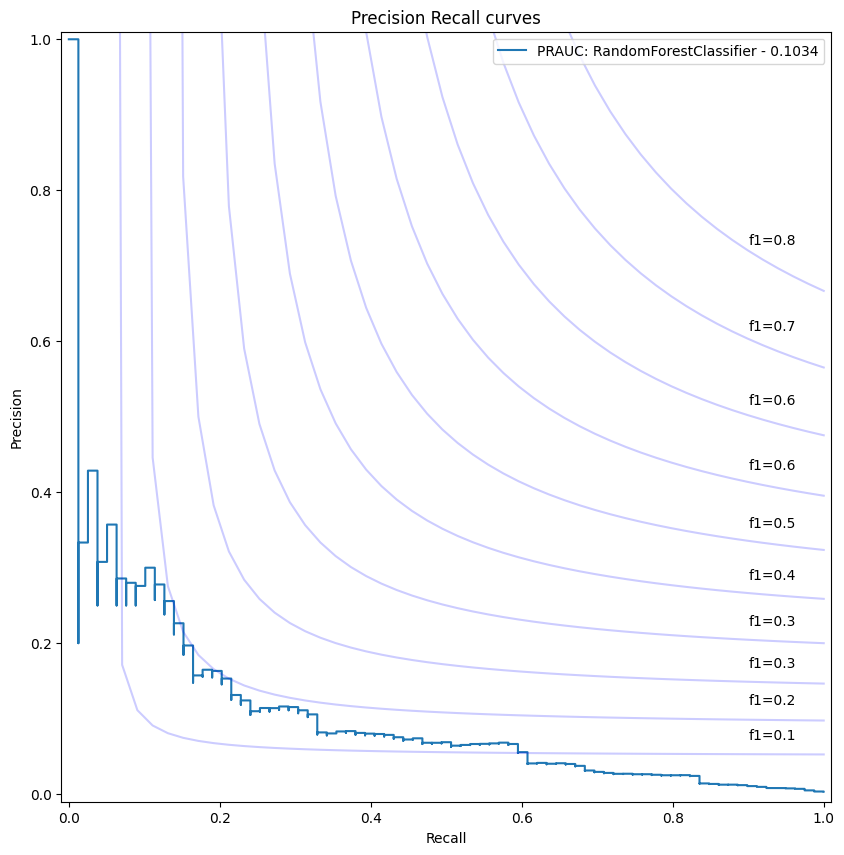

In [33]:
from analysis.utils.graphs import plot_precision_recall
from analysis.utils.columns import COL_TARGET


probas_pred_rf: np.ndarray = model_rf.predict_proba(dataset=sample.get_dataset(ds_type=DatasetType.TEST))
probas_pred_rf = probas_pred_rf[:, 1]

_ = plot_precision_recall(
    binary_true=sample.get_label(ds_type=DatasetType.TEST), 
    model_probas={"RandomForestClassifier": probas_pred_rf}
)

<h4>TOP-K or Hit ratio</h4>

<p>This metric measures the change of getting the only positive given we take K highest logits</p>

In [36]:
from analysis.utils.metrics import calculate_topk

?calculate_topk

Signature:
calculate_topk(
    model: analysis.models.BaseModel.ImplementsRank,
    dataset: analysis.utils.dataset.Dataset,
    bins: Iterable[float],
) -> pandas.core.series.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/cryptocurrency_pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

In [40]:
dataset: Dataset = sample.get_dataset(ds_type=DatasetType.TEST)

calculate_topk(model=model_rf, dataset=dataset, bins=[1, 2, 5, 10, 20, 30])

1     0.000000
2     0.000000
5     0.012658
10    0.012658
20    0.050633
30    0.088608
dtype: float64

<h4>TOP-K%</h4>

In [41]:
from analysis.utils.metrics import calculate_topk_percent

?calculate_topk

Signature:
calculate_topk(
    model: analysis.models.BaseModel.ImplementsRank,
    dataset: analysis.utils.dataset.Dataset,
    bins: Iterable[float],
) -> pandas.core.series.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/cryptocurrency_pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

In [43]:
calculate_topk_percent(model=model_rf, dataset=dataset, bins=[0.01, 0.03, 0.05, 0.1, 0.2, 0.3])

0.01    0.000000
0.03    0.012658
0.05    0.025316
0.10    0.088608
0.20    0.177215
0.30    0.265823
dtype: float64

<h4>TOP-K% AUC</h4>

In [45]:
from analysis.utils.metrics import calculate_topk_percent_auc

calculate_topk_percent_auc(model=model_rf, dataset=dataset)

0.47882911392405075

<h4>TopKPortfolio</h4>

In [50]:
from analysis.portfolio.TOPKPortfolio import TOPKPortfolio
from core.pump_event import PumpEvent
from core.currency_pair import CurrencyPair
from core.exchange import Exchange
from datetime import datetime

pump: PumpEvent = PumpEvent(
    currency_pair=CurrencyPair.from_string("ACM-BTC"),
    time=datetime.strptime("2021-06-05 18:00:13", "%Y-%m-%d %H:%M:%S"),
    exchange=Exchange.BINANCE_SPOT
)

manager = TOPKPortfolio(model=model_rf, portfolio_size=10)
manager.evaluate_cross_section(dataset=dataset, pump=pump)

(np.float64(0.0200596916778762),
 Portfolio: {CurrencyPair(base='GTO', term='BTC'): np.float64(0.1), CurrencyPair(base='EVX', term='BTC'): np.float64(0.1), CurrencyPair(base='YOYO', term='BTC'): np.float64(0.1), CurrencyPair(base='CKB', term='BTC'): np.float64(0.1), CurrencyPair(base='NXS', term='BTC'): np.float64(0.1), CurrencyPair(base='CND', term='BTC'): np.float64(0.1), CurrencyPair(base='BCD', term='BTC'): np.float64(0.1), CurrencyPair(base='FUN', term='BTC'): np.float64(0.1), CurrencyPair(base='ARDR', term='BTC'): np.float64(0.1), CurrencyPair(base='SNGLS', term='BTC'): np.float64(0.1)})

<h4>CatboostClassifier</h4>

In [53]:
sample.init_pools()

In [54]:
from analysis.models.catboost import CatboostClassifierModel

model_cb: CatboostClassifierModel = CatboostClassifierModel(
    params={
        "objective": "Logloss",
        "num_boost_round": 1000,
        "auto_class_weights": "Balanced",
    }
)
model_cb.train(sample=sample)

In [55]:
calculate_topk(model=model_cb, dataset=dataset, bins=[1, 2, 5, 10, 20, 30])

1     0.000000
2     0.012658
5     0.012658
10    0.012658
20    0.037975
30    0.075949
dtype: float64